In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv(
    "Market_Basket_Optimisation.csv",
    header=None
)

print(df.shape)
df.head()

(7501, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
transactions = []

for i in range(len(df)):
    items = df.iloc[i].dropna().astype(str).tolist()
    transactions.append(items)

print(transactions[:5])

[['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil'], ['burgers', 'meatballs', 'eggs'], ['chutney'], ['turkey', 'avocado'], ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]


In [4]:
mlb = MultiLabelBinarizer()

X = mlb.fit_transform(transactions)

encoded_df = pd.DataFrame(
    X,
    columns=mlb.classes_
)

print(encoded_df.shape)
encoded_df.head()

(7501, 120)


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,0,1,1,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [5]:
X_sample = X[:500]

print(X_sample.shape)

(500, 120)


In [6]:
linked = linkage(
    X_sample,
    method="ward"
)

print("Linkage matrix created successfully.")

Linkage matrix created successfully.


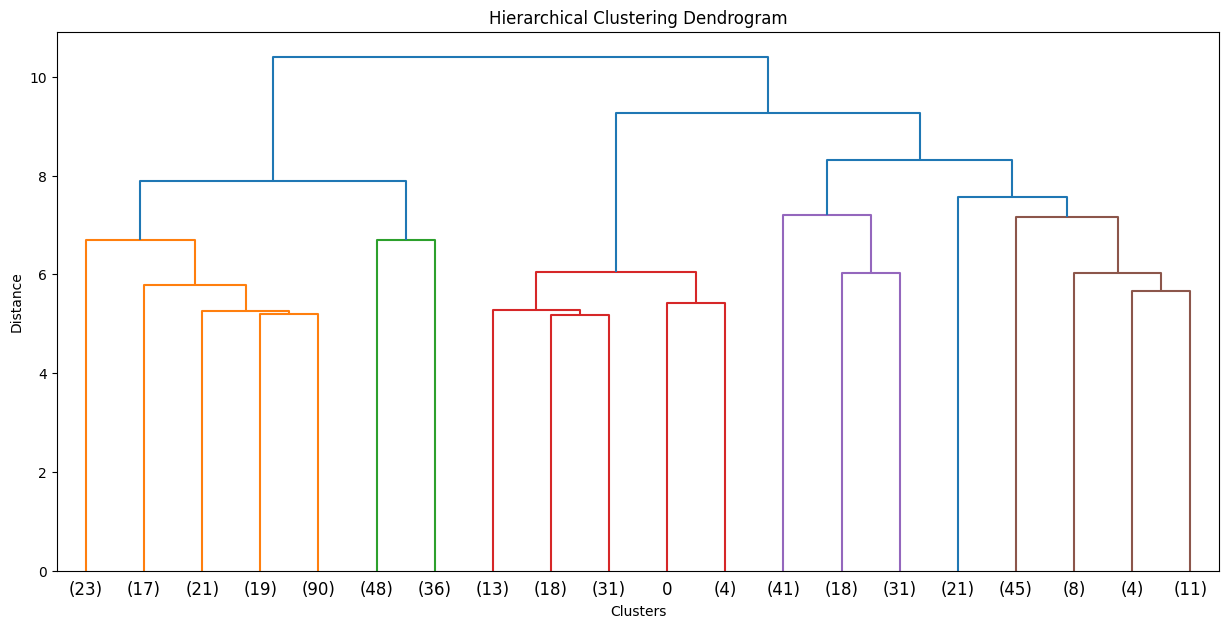

In [7]:
plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

In [8]:
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

clusters = hc.fit_predict(X)

print(clusters[:20])

[1 1 1 1 1 1 0 1 0 1 1 2 1 1 1 0 3 1 1 0]


In [9]:
result_df = df.copy()

result_df["Cluster"] = clusters

result_df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,Cluster
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,...,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil,1
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
6,whole wheat pasta,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,soup,light cream,shallot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
8,frozen vegetables,spaghetti,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [10]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()

print("Transactions in each cluster:")
print(cluster_counts)

Transactions in each cluster:
0    2317
1    4552
2     289
3     343
Name: count, dtype: int64


In [11]:
encoded_df["Cluster"] = clusters

for cluster in range(4):

    cluster_data = encoded_df[
        encoded_df["Cluster"] == cluster
    ].drop("Cluster", axis=1)

    top_products = (
        cluster_data.mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nCluster", cluster)
    print("Top Products:")

    for product in top_products.index:
        print(product)


Cluster 0
Top Products:
mineral water
spaghetti
milk
ground beef
chocolate
frozen vegetables
eggs
olive oil
burgers
shrimp

Cluster 1
Top Products:
french fries
eggs
mineral water
green tea
pancakes
chocolate
escalope
cake
milk
spaghetti

Cluster 2
Top Products:
cookies
eggs
french fries
mineral water
green tea
cake
milk
brownies
avocado
muffins

Cluster 3
Top Products:
chocolate
french fries
escalope
spaghetti
champagne
eggs
whole wheat rice
low fat yogurt
shrimp
grated cheese


In [12]:
result_df.to_csv(
    "Hierarchical_Clustered_Market_Basket.csv",
    index=False
)

print("Hierarchical clustered dataset saved successfully.")

Hierarchical clustered dataset saved successfully.
